# 과제 3.2 매개변수화된 회로 구성하기

**개요:** 이 노트북은 매개변수화된 회로를 구성하는 방법을 다룹니다.

Qiskit에서 매개변수화된 회로는 매개변수를 조정하여 다양한 작업에 적응할 수 있는 유연한 양자 알고리즘을 만드는 데 사용됩니다. 먼저 다음 내용을 살펴봅니다:

*   **Parameter 클래스**와 그 속성 및 메서드
*   **양자 회로**와 회로에서 매개변수를 사용하는 방법
*   **매개변수 표현식**과 사용 시점


In [2]:
import numpy as np
from qiskit.circuit import QuantumCircuit, Parameter

## 목표 1: Parameter (매개변수)

Qiskit에서 `Parameter` 클래스를 사용하면 양자 회로에서 사용할 수 있는 기호 변수를 만들 수 있습니다. 이러한 매개변수는 회로가 실행될 때까지 바인딩되지 않은 상태로 유지되며, 이를 통해 매개변수화된 양자 회로를 생성할 수 있습니다.

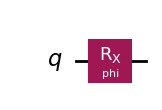

In [2]:
 # 'phi'라는 이름의 매개변수 기호 변수를 생성
phi = Parameter('phi')
qc = QuantumCircuit(1)
 
# 양자 게이트에서 숫자 값 대신 매개변수를 사용
# 매개변수가 할당될 때까지 회로는 바인딩되지 않은 상태로 유지됨
qc.rx(phi, 0)
qc.draw('mpl')

매개변수는 회로가 생성된 후에 값이 할당됩니다. 동일한 회로를 서로 다른 매개변수 값으로 여러 번 실행할 수 있습니다.

매개변수화된 회로:
phi = π


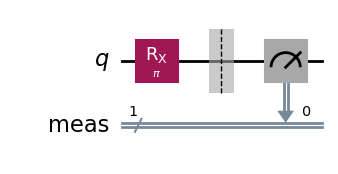

In [3]:
# 회로 생성 후 매개변수를 바인딩하여 바인딩된 회로를 생성
# 동일한 회로 또는 그 복사본에 할당 가능
qc = qc.assign_parameters({phi: np.pi})
qc.measure_all()
print("매개변수화된 회로:")
print("phi = π")
qc.draw('mpl')

### 속성

| 속성 | 설명 | 비고 |
|-----------|-------------|-------------------|
| **`name`** | 매개변수 이름 |  |
| **`uuid`** | 매개변수 식별자 |  |


In [8]:
print(f"매개변수 이름: {phi.name}")
print(f"매개변수 UUID: {phi.uuid}")

매개변수 이름: phi
매개변수 UUID: ef7e43b9-92e3-4027-a1fe-d12f483aa121


### 메서드

* **abs** : 매개변수의 절댓값.
* **arccos**: 매개변수의 아크코사인.
* **arcsin**: 매개변수의 아크사인.
* **arctan**: 매개변수의 아크탄젠트.
* **assign**: 하나의 매개변수에 값을 할당.
* **bind**: 매개변수에 값을 바인딩.
* **conjugate**: 매개변수의 켤레복소수.
* **cos**: 매개변수의 코사인.
* **exp**: 매개변수의 지수함수.
* **gradient**: 입력 매개변수에 대한 미분값.
* **is_real**: 매개변수가 실수인지 확인.
* **log** : 매개변수의 자연로그.
* **numeric**: 매개변수를 숫자 값으로 변환.
* **sign**: 매개변수의 부호를 반환.
* **sin**: 매개변수의 사인.
* **subs**: 매개변수를 대체한 새 표현식을 반환.
* **sympify**: 매개변수의 SymPy 등가 표현.
* **tan**: 매개변수의 탄젠트.


In [9]:
print(f"Sin: {phi.sin()}")
print(f"Cos: {phi.cos()}")
print(f"tan: {phi.tan()}")

Sin: sin(phi)
Cos: cos(phi)
tan: tan(phi)


## 목표 2: 양자 회로 (Quantum Circuit)

`QuantumCircuit` 클래스는 Qiskit에서 양자 프로그램의 기본 구성 요소입니다. 양자 게이트와 연산의 모음을 나타냅니다.

매개변수는 여러 큐비트와 게이트 유형에 걸쳐 사용할 수 있으며, 회로는 여러 개의 매개변수를 포함할 수 있습니다.

아래 예제는 여러 매개변수를 가진 회로를 보여줍니다. 회로에서 바인딩되지 않은 모든 매개변수를 가져오려면 `parameters` 속성을 사용할 수 있습니다.

다중 매개변수 회로:
회로 매개변수: ParameterView([Parameter(γ), Parameter(θ)])


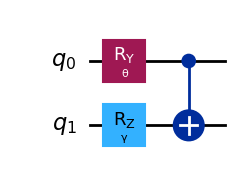

In [10]:
# 다중 매개변수 회로 생성
theta = Parameter('θ')
gamma = Parameter('γ')

qc2 = QuantumCircuit(2)
qc2.ry(theta, 0)
qc2.rz(gamma, 1)
qc2.cx(0, 1)

print("다중 매개변수 회로:")
print(f"회로 매개변수: {qc2.parameters}")
qc2.draw('mpl')


```dict``` 타입을 사용하여 여러 매개변수에 값을 바인딩합니다

바인딩된 회로 값:
theta = π/2, gamma = π/4


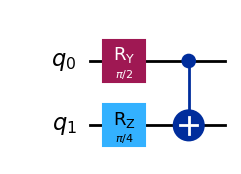

In [11]:
# 여러 가지 방법으로 매개변수 바인딩
param_dict = {theta: np.pi/2, gamma: np.pi/4}

# assign_parameters (새 회로를 반환)
bound_circuit = qc2.assign_parameters(param_dict)


print("바인딩된 회로 값:")
print(f"theta = π/2, gamma = π/4")
bound_circuit.draw('mpl')

## 목표 3: 매개변수 표현식 (Parameter Expression)

`ParameterExpression`은 Parameter의 수학적 표현식을 생성할 수 있게 해주며, 복잡한 매개변수 관계와 제약 조건을 설정할 수 있습니다. 표준 수학 연산을 사용하여 생성되며, 삼각함수, 로그 및 기타 연산도 포함할 수 있습니다.

In [13]:
from qiskit.circuit import Parameter

# 기본 매개변수 생성
x = Parameter('x')
y = Parameter('y')

# 수학적 표현식 생성
expr1 = x + y
expr2 = 2 * x - y**2
expr3 = x.sin() + y.cos()

print(f"표현식 1: {expr1}")
print(f"표현식 2: {expr2}")
print(f"표현식 3: {expr3}")
print(f"expr1의 매개변수: {expr1.parameters}")

표현식 1: x + y
표현식 2: 2*x - y**2
표현식 3: sin(x) + cos(y)
expr1의 매개변수: {Parameter(y), Parameter(x)}


매개변수 표현식은 양자 게이트에 직접 사용할 수 있으며, 회로는 표현식에서 모든 기본 매개변수를 자동으로 추출합니다. 이를 통해 종속 매개변수가 있는 회로를 만들 수 있습니다.

매개변수 표현식이 포함된 회로:
모든 매개변수: ParameterView([Parameter(α), Parameter(β)])


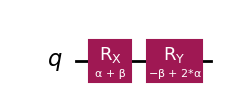

In [30]:
# 매개변수 표현식을 사용한 회로 생성
alpha = Parameter('α')
beta = Parameter('β')

expr = 2 * alpha - beta

qc3 = QuantumCircuit(1)
qc3.rx(alpha + beta, 0)  # 매개변수를 표현식으로 사용하여 회전 각도 지정
qc3.ry(expr, 0) # 생성한 표현식 사용

print("매개변수 표현식이 포함된 회로:")
print(f"모든 매개변수: {qc3.parameters}")
qc3.draw('mpl')


In [37]:
#assign, bound는 원래 객체를 건드리지 않고 새로운 표현을 반환함
expr.assign(alpha, 3.0)
print(expr)

bound_expr = expr.assign(alpha, 3.0)
print(bound_expr)


-β + 2*α
6 - β


더 복잡한 표현식을 만들 수도 있습니다. 이 경우 ```bind()``` 메서드를 사용하여 표현식에 매개변수 값을 할당합니다.

In [17]:
# 복잡한 표현식 생성 및 평가
expr = (x + y) * x.cos() - y**2
print(f"복잡한 표현식: {expr}")

# 매개변수 바인딩 및 평가
param_values = {x: 1.0, y: 2.0}
bound_expr = expr.bind(param_values)
numeric_value = float(bound_expr)

print(f"바인딩된 표현식: {bound_expr}")
print(f"수치 값: {numeric_value}")

복잡한 표현식: (x + y)*cos(x) - y**2
바인딩된 표현식: -2.3790930823955807
수치 값: -2.3790930823955807


In [20]:
bound_expr.numeric()

-2.3790930823955807

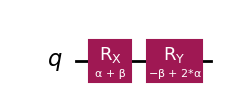

In [39]:
#assign parameters test

param_values = {alpha: 1.0, beta: 2.0}

qc3.assign_parameters(param_values)
qc3.draw('mpl')

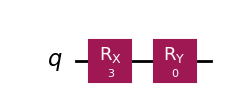

In [ ]:
#assign parameters returns a new instance
qc3_binded = qc3.assign_parameters(param_values)
qc3_binded.draw('mpl')

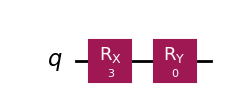

In [ ]:
#assign parameters inplace=True test
qc3.assign_parameters(param_values, inplace=True)
qc3.draw('mpl')

In [ ]:
#bind_all test

x = Parameter('x')
y = Parameter('y')
z = Parameter('z')

expr = x + y * 2

# 많은 표현식에 같은 딕셔너리를 돌려쓸 때 유리
values = {x: 1.0, y: 2.0, z: 3.0}  

result_bind = expr.bind({x: 1.0, y: 2.0})
result_bind_all = expr.bind_all({x: 1.0, y: 2.0})

print(type(result_bind))      # <class 'ParameterExpression'>
print(type(result_bind_all))  # <class 'float'>


<class 'qiskit._accelerate.circuit.ParameterExpression'>
<class 'float'>


In [ ]:
# bind_all — 바로 숫자니까 그냥 됨
print(result_bind_all + 10)    # 15.0 
print(result_bind_all > 3)     # True 

# bind — ParameterExpression이라 일반 연산에서 문제
print(result_bind + 10)        # 또 다른 ParameterExpression
print(result_bind > 3)         # 에러 발생

15.0
True
15


TypeError: '>' not supported between instances of 'qiskit._accelerate.circuit.ParameterExpression' and 'int'

---
# 요약
---

이 노트북에서 다룬 내용:

## 매개변수화된 회로 구성:

1. **Parameter 클래스를 사용**하여 기호 변수를 생성하며, 회로가 생성된 후에 값을 할당합니다.
2. **양자 회로**는 하나 이상의 매개변수로 생성할 수 있으며, 이후 매개변수에 값을 할당할 수 있습니다.
3. **매개변수 표현식**을 사용하여 매개변수 간의 복잡한 관계와 제약 조건을 설정할 수 있습니다.



---

## 연습 문제

**1) 다음 코드에서 ```qc.assign_parameters({theta: np.pi/2})```는 무엇을 하나요?**

```
theta = Parameter("θ")

qc = QuantumCircuit(1)

qc.ry(theta, 0)

qc.assign_parameters({theta: np.pi/2},inplace=True)

```

A) ry를 측정으로 대체한다

B) 매개변수를 제거하고 회전 각도를 pi/2로 설정한다

C) theta에 의존하는 새로운 회로를 생성한다

D) 매개변수를 업데이트할 수 없으므로 런타임 오류가 발생한다

E) assign_parameters를 동일한 회로에 할당할 수 없으므로 런타임 오류가 발생한다


***정답:***
<Details>
<br/>
B) 매개변수를 제거하고 회전 각도를 pi/2로 설정한다
assign_parameters는 매개변수에 값을 매핑하며, 동일한 회로 또는 그 복사본에 사용할 수 있습니다.
</Details>


In [4]:
theta = Parameter("θ")

qc = QuantumCircuit(1)

qc.ry(theta, 0)

qc = qc.assign_parameters({theta: np.pi/2},inplace=True)
qc.draw('mpl')

AttributeError: 'NoneType' object has no attribute 'draw'

---

**2) x와 y가 Qiskit Parameter 객체일 때 $2x - y^2$와 같은 수학적 표현식을 어떻게 만들 수 있나요?**

A) ```expr = Expression(2*x - y**2)```

B) ```expr = ParameterMath(2*x - y**2)```

C) ```expr = 2*x - y**2```

D) ```expr = ParameterExpression(2*x - y**2)```

E) ```expr = CircuitExpression(x, y, lambda x,y: 2*x - y**2)```


***정답:***
<Details>
<br/>
C) expr = 2*x - y**2

Qiskit의 Parameter 객체는 표준 Python 산술 연산을 지원하며, 이를 통해 자동으로 ParameterExpression 객체가 생성됩니다. 별도의 특수 생성자는 필요하지 않습니다.

</Details>
